In [9]:
import h5py
filename = "arxiv-nomic-768-normalized.hdf5"

with h5py.File(filename, "r") as f:
    arrays = f['train'][()]
    queries = f['test'][()]

In [10]:
from tests.error_test import test_top_k_sketches, test_top_k_sketches_asym
from src.adaptive_separate_and_sketch import ASaS
from src.simhash import SH
from src.true_sample_and_sketch import Sample_and_sketch
from src.separate_and_sketch import SaS
from src.jl_cs import JL
from src.my_priority_sampling import PS

class SimpleJL:
    def __init__(self, size, seed):
        self.sketcher = JL(size // 64, seed)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleASaS:
    def __init__(self, size, seed):
        self.sketcher = ASaS(size, seed, SH, dim=arrays[0].shape[0])

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    

class SimpleSepareteAndSketch50:
    def __init__(self, size, seed):
        self.sketcher = SaS(int(0.5 * size), int(0.5 * size), seed, SH, dim=arrays[0].shape[0])
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleSH:
    def __init__(self, size, seed):
        self.sketcher = SH(size, seed, dim=arrays[0].shape[0])
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    def get_matrix(self):
        return self.sketcher.get_matrix()



In [11]:
from src.quantize_ps import PSQ

class SimplePSQ4:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=4)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ8:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=8)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ9:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=9)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ10:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=10)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ11:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=11)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    

    
class SimplePSQ12:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=12)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ13:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=13)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ14:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=14)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ16:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=16)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()

In [12]:
print(test_top_k_sketches([SimplePSQ8, SimplePSQ9, SimplePSQ10, SimplePSQ11, SimplePSQ12, SimplePSQ13, SimplePSQ14, SimplePSQ16],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 1, ['PSQ 8 bits', 'PSQ 9 bits', 'PSQ 10 bits', 'PSQ 11 bits', 'PSQ 12 bits', 
                                                                                 'PSQ 13 bits', 'PSQ 14 bits', 'PSQ 16 bits', 'ASAS'], "Splade top 1"))

TypeError: test_top_k_sketches() missing 1 required positional argument: 'markers'

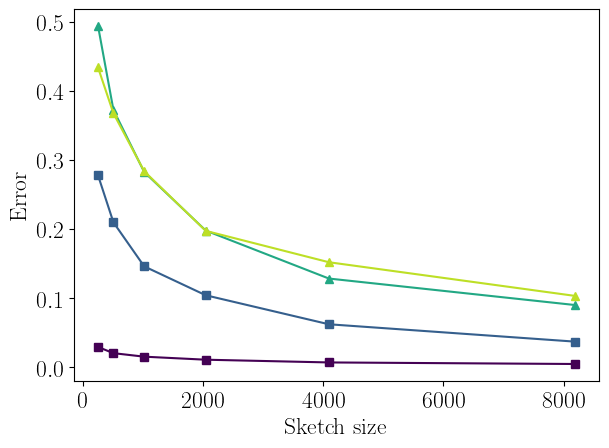

[[0.029572450566310506, 0.020618125575846583, 0.015534395926338247, 0.011137805836676382, 0.007177478099636123, 0.0049239937643294415], [0.2783025341799728, 0.2101524217662451, 0.14636130948746082, 0.10447837066969771, 0.062466957875246164, 0.037299690079612806], [0.4946637936712475, 0.37307552491828794, 0.283049717987948, 0.1982120489521444, 0.1287019996648165, 0.09031445647965627], [0.43449489684121056, 0.36809401895385113, 0.28409456107553605, 0.19777143054101168, 0.1523379507851796, 0.10353626519604467]]


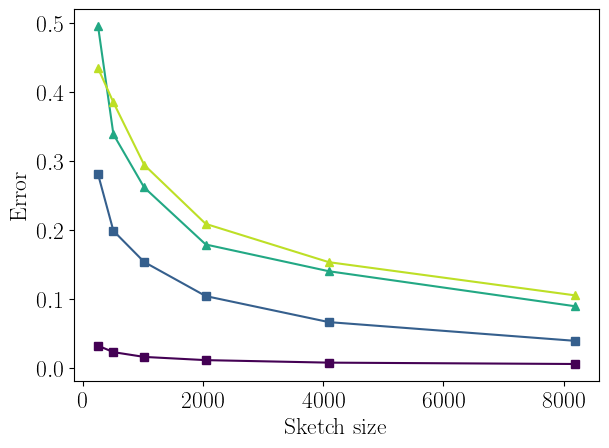

[[0.03175152213176795, 0.022355358906358744, 0.015446114052059895, 0.010783510990074857, 0.007146869743199669, 0.005181578553637953], [0.280332176297317, 0.1981293509275795, 0.15297082943438225, 0.10358964487813131, 0.06587317717945876, 0.038735579750023494], [0.49512140795082743, 0.33802208371253506, 0.26096637499696557, 0.17833529731711745, 0.13960258508166315, 0.08884530003736077], [0.4339419099692644, 0.3842577558461518, 0.2936964520844208, 0.20819401141365135, 0.15273124700515361, 0.10462470815949555]]


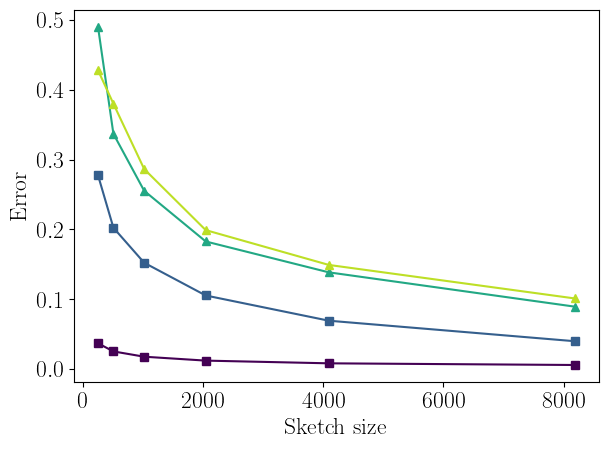

[[0.03721416569312057, 0.02560447778815121, 0.018032209378126503, 0.012435379328134707, 0.008568506618234323, 0.00617450300043538], [0.27759479424369343, 0.20247947800776975, 0.15240843983133417, 0.10558555316560062, 0.06951564176453309, 0.04014415452826732], [0.4897650339604821, 0.33682271193561136, 0.2553156192990887, 0.182847068787598, 0.13868400981922274, 0.08956186276849712], [0.42772668577669637, 0.37987774699081944, 0.2864280012772637, 0.19907796172477304, 0.14928857739037293, 0.10129723916530267]]


In [13]:
print(test_top_k_sketches([SimpleSH, SimplePSQ12, PS, SimpleJL],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 1, ['SimHash', 'Priority Sampling Quantized', 'Priority Sampling', 'JL'], "Arxiv top 1", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimplePSQ12, PS, SimpleJL],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 10, ['SimHash', 'Priority Sampling Quantized', 'Priority Sampling', 'JL'], "Arxiv top 10", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimplePSQ12, PS, SimpleJL],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 100, ['SimHash', 'Priority Sampling Quantized', 'Priority Sampling', 'JL'], "Arxiv top 100", markers= ['s', 's', '^', '^']))

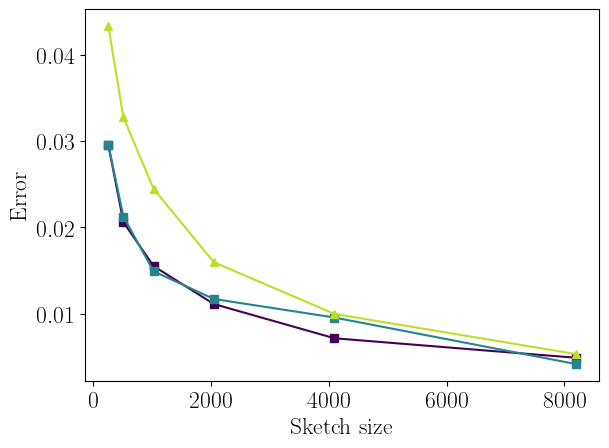

[[0.029572450566310506, 0.020618125575846583, 0.015534395926338247, 0.011137805836676382, 0.007177478099636123, 0.0049239937643294415], [0.029572450566310506, 0.021254804197836055, 0.014926086515151891, 0.011723726122313706, 0.009576881020639187, 0.00420004421461161], [0.04331961250887951, 0.03275171563740947, 0.02446158521869031, 0.01597376921016456, 0.009995935698316525, 0.005353162549267845]]


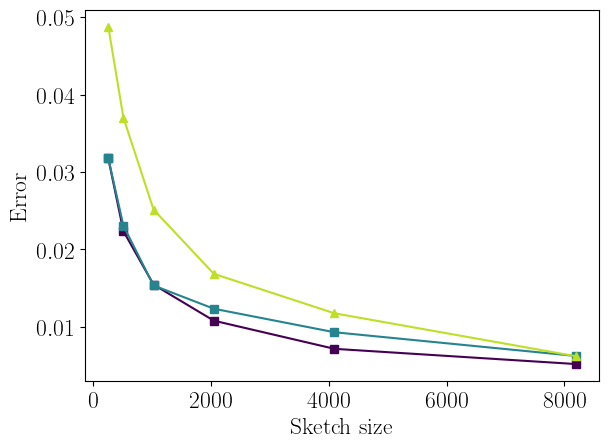

[[0.03175152213176795, 0.022355358906358744, 0.015446114052059895, 0.010783510990074857, 0.007146869743199669, 0.005181578553637953], [0.03175152213176795, 0.023060586811714537, 0.015334316023810924, 0.012327248923950903, 0.00928946963554737, 0.0062275818894408745], [0.04876272025387425, 0.03703046005621475, 0.02514078410235082, 0.016836362657121445, 0.011738781825409585, 0.006194820964780255]]


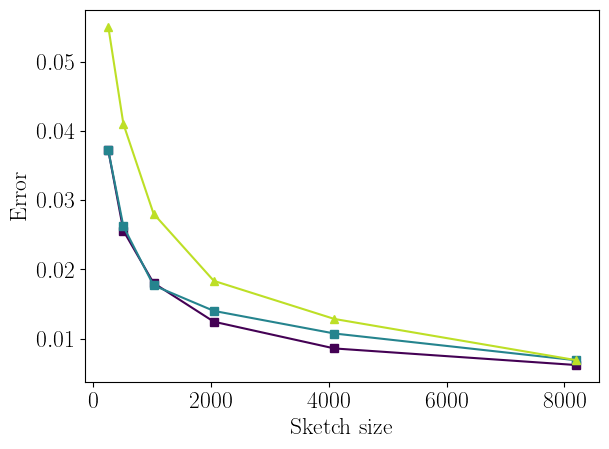

[[0.03721416569312057, 0.02560447778815121, 0.018032209378126503, 0.012435379328134707, 0.008568506618234323, 0.00617450300043538], [0.03721416569312057, 0.02622885934300416, 0.017691526277231622, 0.013999585297550592, 0.010728939171102422, 0.006867826854392613], [0.0550814093321296, 0.041044738007990064, 0.028064186382473322, 0.018343368592375647, 0.012832736276917856, 0.006886604080771211]]


In [14]:
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 1, ['SimHash', 'Adaptive Select and Sketch', 'Separate and Sketch 50/50 Split', 'JL'], "ASAS Arxiv top 1", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 10, ['SimHash', 'Adaptive Select and Sketch', 'Separate and Sketch 50/50 Split', 'JL'], "ASAS Arxiv top 10", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048, 4096, 8192], 10, arrays, queries[:10], 100, ['SimHash', 'Adaptive Select and Sketch', 'Separate and Sketch 50/50 Split', 'JL'], "ASAS Arxiv top 100", markers= ['s', 's', '^', '^']))